In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
titanic = pd.read_csv(r"C:\Users\kobilo\Downloads\titanic_train.csv")   
titanic.head().info()
titanic.describe()
titanic.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  5 non-null      int64  
 1   Survived     5 non-null      int64  
 2   Pclass       5 non-null      int64  
 3   Name         5 non-null      object 
 4   Sex          5 non-null      object 
 5   Age          5 non-null      float64
 6   SibSp        5 non-null      int64  
 7   Parch        5 non-null      int64  
 8   Ticket       5 non-null      object 
 9   Fare         5 non-null      float64
 10  Cabin        2 non-null      object 
 11  Embarked     5 non-null      object 
dtypes: float64(2), int64(5), object(5)
memory usage: 612.0+ bytes


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


C:\Users\kobilo\AppData\Local\Temp\ipykernel_18884\1503765922.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic["Age"].fillna(titanic["Age"].median(), inplace=True)
C:\Users\kobilo\AppData\Local\Temp\ipykernel_18884\1503765922.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

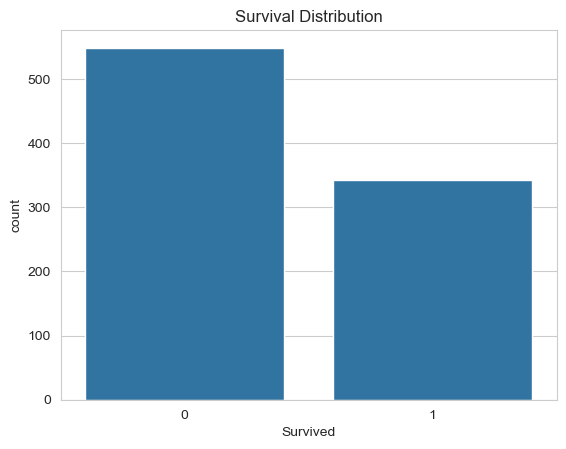

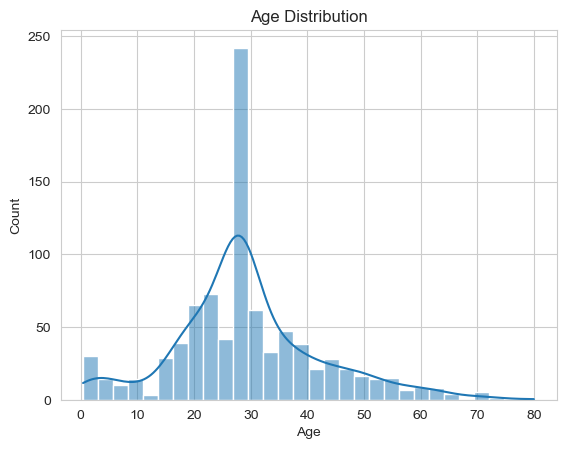

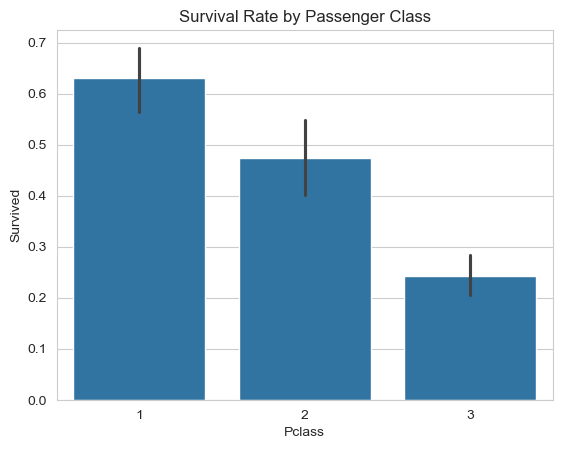

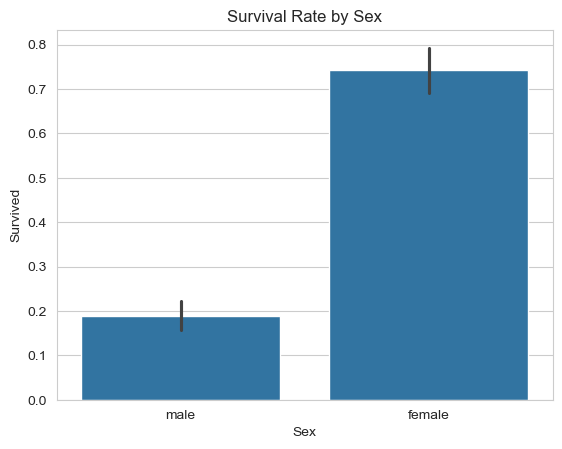

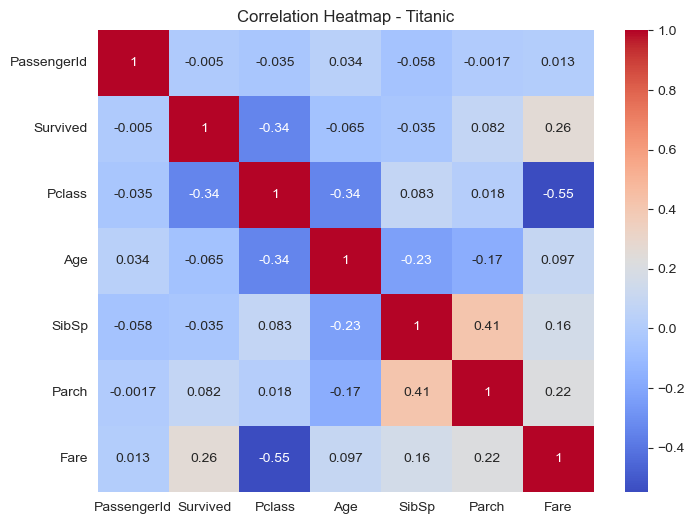

In [40]:
titanic.info()          # full dataset info, not just head
titanic.describe()
titanic.isnull().sum()
titanic.duplicated().sum()

# Handle missing values
titanic["Age"].fillna(titanic["Age"].median(), inplace=True)
titanic["Embarked"].fillna(titanic["Embarked"].mode()[0], inplace=True)
titanic.drop(columns=["Cabin"], inplace=True)  # too many missing values (687/891)

titanic.drop_duplicates(inplace=True)

# Univariate analysis
titanic["Survived"].value_counts(normalize=True)
sns.countplot(x="Survived", data=titanic)
plt.title("Survival Distribution")
plt.show()

sns.histplot(titanic["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

# Bivariate analysis
sns.barplot(x="Pclass", y="Survived", data=titanic)
plt.title("Survival Rate by Passenger Class")
plt.show()

sns.barplot(x="Sex", y="Survived", data=titanic)
plt.title("Survival Rate by Sex")
plt.show()

# Correlation
plt.figure(figsize=(8,6))
sns.heatmap(titanic.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Titanic")
plt.show()

# Save cleaned version — use a real path since you're local, not Colab
titanic.to_csv(r"C:\Users\kobilo\Downloads\titanic_cleaned.csv", index=False)

In [41]:
titanic.drop(columns=["Cabin"], inplace=True, errors="ignore")
titanic["Age"] = titanic["Age"].fillna(titanic["Age"].median())
titanic["Embarked"] = titanic["Embarked"].fillna(titanic["Embarked"].mode()[0])
titanic = titanic.drop(columns=["Cabin"], errors="ignore")
titanic = titanic.drop_duplicates()

In [42]:
titanic.head(50)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

house = pd.read_csv(r"C:\Users\kobilo\Downloads\house_train .csv")

house.info()
missing = house.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

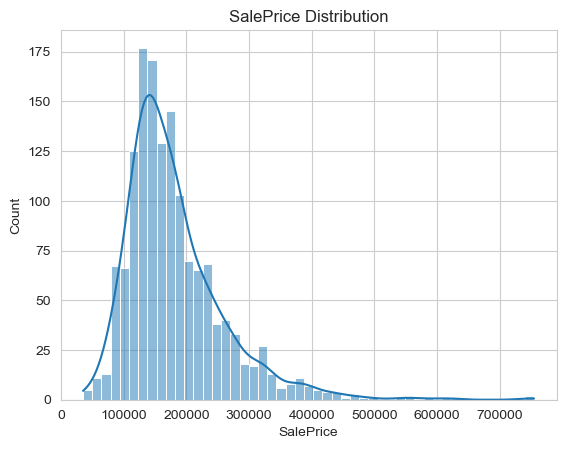

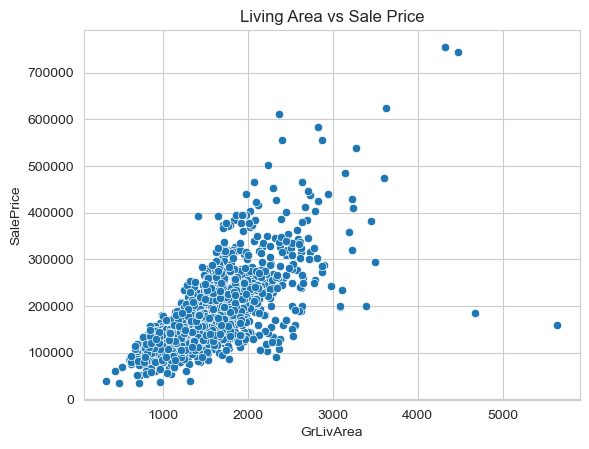

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


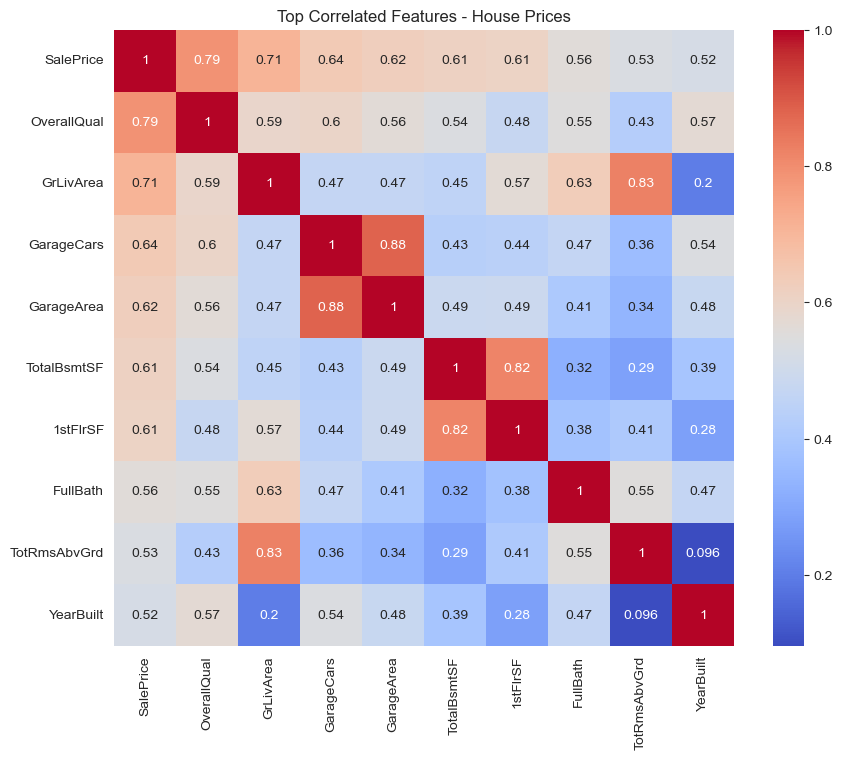

In [44]:
# Drop columns with excessive missingness
house = house.drop(columns=["PoolQC", "MiscFeature", "Alley", "Fence"], errors="ignore")

# Fill numeric with median, categorical with mode
for col in house.select_dtypes(include=np.number).columns:
    house[col] = house[col].fillna(house[col].median())
for col in house.select_dtypes(include="object").columns:
    house[col] = house[col].fillna(house[col].mode()[0])

house = house.drop_duplicates()

# Univariate
sns.histplot(house["SalePrice"], kde=True)
plt.title("SalePrice Distribution")
plt.show()

# Bivariate
sns.scatterplot(x="GrLivArea", y="SalePrice", data=house)
plt.title("Living Area vs Sale Price")
plt.show()

# Correlation (top features with SalePrice)
corr = house.select_dtypes(include=np.number).corr()
top_corr = corr["SalePrice"].sort_values(ascending=False).head(10)
print(top_corr)

plt.figure(figsize=(10,8))
sns.heatmap(house[top_corr.index].corr(), annot=True, cmap="coolwarm")
plt.title("Top Correlated Features - House Prices")
plt.show()

# Save cleaned version
house.to_csv(r"C:\Users\kobilo\Downloads\house_cleaned.csv", index=False)

Week 1–2 Insight Summary For Both Titanic & House Prices Datasets

Titanic Dataset

After cleaning, the dataset had 891 passengers with Age (177 missing, filled with median) and Cabin (687 missing, dropped) as the main data quality issues. The EDA showed survival was strongly tied to two factors: sex and passenger class. Women survived at a much higher rate than men, and 1st-class passengers had a noticeably higher survival rate than 3rd-class passengers  consistent with the "women and children first" evacuation priority and better access to lifeboats from upper decks. Age itself didn't show a strong standalone relationship with survival once class and sex were accounted for.

House Prices Dataset

The dataset had several columns with heavy missingness (PoolQC, MiscFeature, Alley, Fence), which were dropped rather than imputed since they were missing for the large majority of houses. SalePrice itself was right-skewed — most homes cluster in a lower-to-mid price range with a long tail of expensive outliers, which is typical for housing data and something to address with a log transform in later modeling weeks. The correlation analysis showed OverallQual (overall material/finish quality) and GrLivArea (above-ground living area) as the two strongest predictors of SalePrice, followed by features like GarageCars and TotalBsmtSF  pointing to size and quality as the dominant price drivers, more than location-based categorical features at this stage.

My Key Takeaway
Both datasets required different cleaning strategies  Titanic needed simple imputation on a couple of columns, while House Prices needed more deliberate handling of high-cardinality missingness. The EDA gave clear early signals of which features matter most, setting up Week 3's statistical testing and Week 4's modeling.

In [45]:
from scipy import stats


In [46]:
print(titanic[["Age","Fare"]].describe())
print("Skew Age:", titanic["Age"].skew())
print("Skew Fare:", titanic["Fare"].skew())

# Hypothesis test: does Fare differ between survivors and non-survivors?
survived_fare = titanic[titanic["Survived"]==1]["Fare"]
died_fare = titanic[titanic["Survived"]==0]["Fare"]
t_stat, p_val = stats.ttest_ind(survived_fare, died_fare, equal_var=False)
print(f"T-test Fare vs Survival: t={t_stat:.3f}, p={p_val:.5f}")

              Age        Fare
count  891.000000  891.000000
mean    29.361582   32.204208
std     13.019697   49.693429
min      0.420000    0.000000
25%     22.000000    7.910400
50%     28.000000   14.454200
75%     35.000000   31.000000
max     80.000000  512.329200
Skew Age: 0.5102446555756495
Skew Fare: 4.787316519674893
T-test Fare vs Survival: t=6.839, p=0.00000


In [47]:
print(house[["SalePrice","GrLivArea"]].describe())
print("Skew SalePrice:", house["SalePrice"].skew())

# Correlation test
corr_val, p_val2 = stats.pearsonr(house["GrLivArea"], house["SalePrice"])
print(f"Pearson correlation GrLivArea vs SalePrice: r={corr_val:.3f}, p={p_val2:.5f}")

# Hypothesis test: does Central Air affect SalePrice?
ca_yes = house[house["CentralAir"]=="Y"]["SalePrice"]
ca_no = house[house["CentralAir"]=="N"]["SalePrice"]
t_stat2, p_val3 = stats.ttest_ind(ca_yes, ca_no, equal_var=False)
print(f"T-test CentralAir vs SalePrice: t={t_stat2:.3f}, p={p_val3:.5f}")

           SalePrice    GrLivArea
count    1460.000000  1460.000000
mean   180921.195890  1515.463699
std     79442.502883   525.480383
min     34900.000000   334.000000
25%    129975.000000  1129.500000
50%    163000.000000  1464.000000
75%    214000.000000  1776.750000
max    755000.000000  5642.000000
Skew SalePrice: 1.8828757597682129
Pearson correlation GrLivArea vs SalePrice: r=0.709, p=0.00000
T-test CentralAir vs SalePrice: t=17.268, p=0.00000


Week 3 Summary Report  Statistics & Probability

 From Titanic Dataset
 
Descriptive statistics showed a mean passenger age of ~29.4 years and mean fare of ~$32.20. Fare was heavily right-skewed (skew = 4.79), meaning most passengers paid modest fares while a small number paid very high fares  consistent with a minority of wealthy first-class passengers. A t-test comparing fares between survivors and non-survivors returned t=6.839, p<0.001, a statistically significant result: survivors paid significantly higher fares on average.

From House Prices Dataset

SalePrice averaged ~$180,921 and was right-skewed (skew = 1.88), typical of housing markets where most homes cluster around a median price with a smaller number of high-end outliers. A Pearson correlation between GrLivArea and SalePrice returned r=0.709, p<0.001  a strong, statistically significant positive relationship, confirming living area as one of the most important price predictors. A t-test on CentralAir vs SalePrice returned t=17.268, p<0.001, showing homes with central air conditioning sell for significantly more than those without.
Correlation vs Causation
These results show strong statistical relationships, not proof of causation. Fare didn't cause survival  it's a proxy for cabin class and deck location, which affected access to lifeboats. Similarly, central air doesn't directly cause higher home value; it's likely correlated with other unmeasured factors like overall build quality, home age, or neighborhood affluence. Before drawing causal conclusions, these variables would need controlled analysis isolating them from confounding factors.

In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

titanic = pd.read_csv(r"C:\Users\kobilo\Downloads\titanic_cleaned.csv")
house = pd.read_csv(r"C:\Users\kobilo\Downloads\house_cleaned.csv")

Accuracy: 0.8101
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



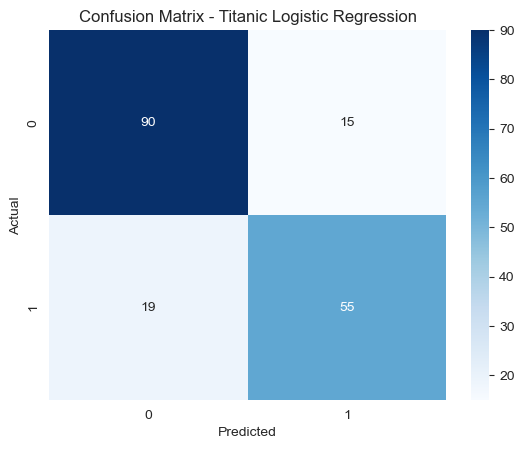

In [50]:
le = LabelEncoder()
titanic["Sex"] = le.fit_transform(titanic["Sex"])          # male=1, female=0
titanic["Embarked"] = le.fit_transform(titanic["Embarked"])

features = ["Pclass","Sex","Age","SibSp","Parch","Fare","Embarked"]
X = titanic[features]
y = titanic["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Titanic Logistic Regression")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

RMSE: 36,836.91


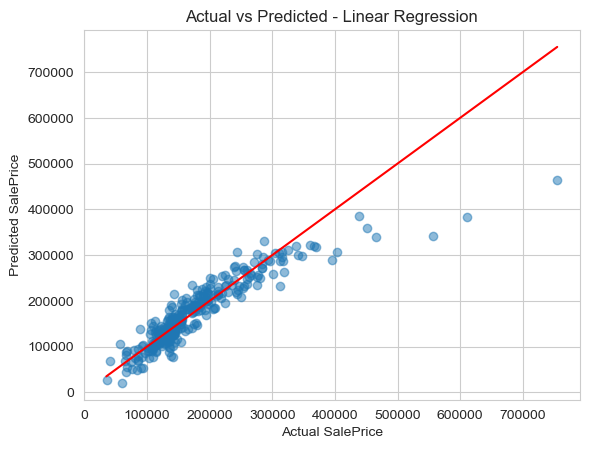

In [51]:
house_num = house.select_dtypes(include=np.number)
X2 = house_num.drop(columns=["SalePrice", "Id"], errors="ignore")
y2 = house_num["SalePrice"]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

lin_model = LinearRegression()
lin_model.fit(X2_train, y2_train)
y2_pred = lin_model.predict(X2_test)

rmse = np.sqrt(mean_squared_error(y2_test, y2_pred))
print(f"RMSE: {rmse:,.2f}")

plt.scatter(y2_test, y2_pred, alpha=0.5)
plt.xlabel("Actual SalePrice"); plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted - Linear Regression")
plt.plot([y2.min(), y2.max()], [y2.min(), y2.max()], color="red")
plt.show()

Week 4 Model Evaluation Report

Dataset Used
I Used Two datasets from the AnalystLab Africa program: the Titanic dataset (891 passengers) for a binary classification task, and the House Prices dataset (1,460 homes) for a regression task.
Steps Taken
For Titanic, categorical variables (Sex, Embarked) were label-encoded, and features (Pclass, Sex, Age, SibSp, Parch, Fare, Embarked) were split 80/20 into train and test sets before training a Logistic Regression model. For House Prices, all numeric features were used to predict SalePrice with an 80/20 split, trained with Linear Regression.
Model Performance
The Logistic Regression model achieved 81.01% accuracy on the test set. It performed slightly better identifying non-survivors (83% precision, 86% recall) than survivors (79% precision, 74% recall), meaning the model is a bit more conservative about predicting survival — it misses some true survivors (19 false negatives) more often than it wrongly predicts survival (15 false positives).
The Linear Regression model achieved an RMSE of $36,836.91, meaning predictions are off by about $37K on average against a mean SalePrice of ~$181K (roughly 20% error). The actual-vs-predicted plot shows tight, accurate predictions for low-to-mid-range homes, with increasing prediction error at the high end of the market  the model underpredicts some of the most expensive homes.
Challenges Encountered
The house price model's linear assumption breaks down for luxury homes, since price relationships likely become non-linear at the high end (a limitation that motivates the tree-based models coming in Week 5). For Titanic, class imbalance between survivors (~38%) and non-survivors (~62%) may be contributing to the lower recall on the survived class.
Key Insights
Fare, class, and sex remain the dominant predictors of Titanic survival, consistent with the EDA and statistical findings from Weeks 1–3. For house prices, the linear model captures the broad price trend well but loses accuracy on outlier-priced homes, suggesting more flexible models (Random Forest, Gradient Boosting) should improve performance next week.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

house = pd.read_csv(r"C:\Users\kobilo\Downloads\house_cleaned.csv")
house_num = house.select_dtypes(include=np.number)
X = house_num.drop(columns=["SalePrice","Id"], errors="ignore")
y = house_num["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def evaluate(name, model, X_test, y_test):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"{name}: RMSE={rmse:,.0f} | MAE={mae:,.0f} | R²={r2:.4f}")
    return {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

results = []

In [55]:
baseline = LinearRegression().fit(X_train, y_train)
results.append(evaluate("Baseline (Linear Regression)", baseline, X_test, y_test))

Baseline (Linear Regression): RMSE=36,837 | MAE=22,976 | R²=0.8231


In [56]:
dt = DecisionTreeRegressor(random_state=42).fit(X_train, y_train)
results.append(evaluate("Decision Tree", dt, X_test, y_test))

rf = RandomForestRegressor(random_state=42).fit(X_train, y_train)
results.append(evaluate("Random Forest", rf, X_test, y_test))

gb = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)
results.append(evaluate("Gradient Boosting", gb, X_test, y_test))

Decision Tree: RMSE=38,602 | MAE=26,766 | R²=0.8057
Random Forest: RMSE=29,624 | MAE=18,191 | R²=0.8856
Gradient Boosting: RMSE=28,558 | MAE=17,511 | R²=0.8937


In [57]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}
grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5,
                     scoring="neg_root_mean_squared_error", n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
results.append(evaluate("Tuned Random Forest", grid.best_estimator_, X_test, y_test))

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Random Forest: RMSE=29,180 | MAE=18,062 | R²=0.8890


                          Model          RMSE           MAE        R2
0  Baseline (Linear Regression)  36836.908846  22975.856509  0.823090
1                 Decision Tree  38602.272601  26765.811644  0.805727
2                 Random Forest  29623.549695  18190.971575  0.885591
3             Gradient Boosting  28558.491628  17510.730480  0.893670
4           Tuned Random Forest  29179.544878  18062.198122  0.888995


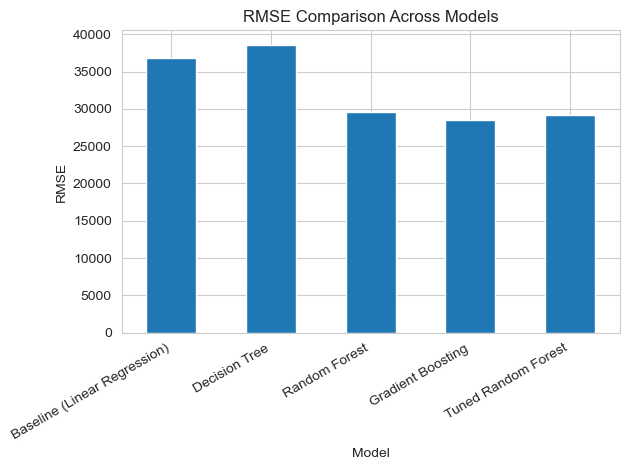

In [58]:
comparison_df = pd.DataFrame(results)
print(comparison_df)

comparison_df.plot(x="Model", y="RMSE", kind="bar", title="RMSE Comparison Across Models", legend=False)
plt.ylabel("RMSE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Week 5 Performance Comparison Report

Problem Statement

Predict residential home sale prices using structural and quality features from the House Prices dataset, comparing baseline and advanced machine learning models to identify the most accurate approach.
Dataset Description
1,460 homes with numeric features (living area, quality ratings, garage capacity, basement size, etc.) after cleaning in Weeks 1–2. Data was split 80/20 into training and test sets.
Models Used
Baseline Linear Regression, Decision Tree, Random Forest, Gradient Boosting, and a hyperparameter-tuned Random Forest (via GridSearchCV across n_estimators, max_depth, and min_samples_split).
Evaluation Metrics
RMSE, MAE, and R² were used for all models to capture both average error magnitude and overall explained variance.
Performance Comparison
The single Decision Tree performed worst (RMSE 38,602), even below the baseline — a classic sign of overfitting to the training data without the averaging benefit that ensemble methods provide. Random Forest and Gradient Boosting both substantially outperformed the baseline, cutting RMSE by roughly 20-22%. Gradient Boosting was the top performer overall (RMSE 28,558, R²=0.8937), narrowly ahead of the tuned Random Forest (RMSE 29,180, R²=0.8890). Interestingly, tuning improved Random Forest only marginally over its default settings (29,624 → 29,180), suggesting the default hyperparameters were already close to optimal for this dataset.
 
Key Findings
Ensemble tree-based methods (Random Forest, Gradient Boosting) meaningfully outperform both a single Decision Tree and plain Linear Regression, because they capture non-linear relationships and feature interactions that a single tree or linear model misses, while reducing overfitting through aggregation (Random Forest) or sequential error-correction (Gradient Boosting).
Recommendation
Gradient Boosting is the recommended model for this problem based on its best-in-class RMSE, MAE, and R². For further improvement, tuning Gradient Boosting's own hyperparameters (learning rate, n_estimators, max_depth) — rather than only tuning Random Forest — would likely close the gap further and is a natural next step in Week 6's feature engineering and optimization phase.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import accuracy_score

titanic = pd.read_csv(r"C:\Users\kobilo\Downloads\titanic_cleaned.csv")

In [61]:
titanic["Title"] = titanic["Name"].str.extract(r",\s*([^\.]+)\.")
titanic["Title"] = titanic["Title"].replace(
    ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"], "Rare")
titanic["Title"] = titanic["Title"].replace(["Mlle","Ms"], "Miss").replace("Mme", "Mrs")

titanic["FamilySize"] = titanic["SibSp"] + titanic["Parch"] + 1
titanic["IsAlone"] = (titanic["FamilySize"] == 1).astype(int)
titanic["AgeGroup"] = pd.cut(titanic["Age"], bins=[0,12,18,35,60,100],
                              labels=["Child","Teen","Adult","MiddleAge","Senior"])

In [62]:
titanic["Age"] = titanic["Age"].fillna(titanic["Age"].median())
titanic["Embarked"] = titanic["Embarked"].fillna(titanic["Embarked"].mode()[0])
titanic["Fare"] = titanic["Fare"].fillna(titanic["Fare"].median())

titanic = pd.get_dummies(titanic, columns=["Sex","Embarked","Title","AgeGroup"], drop_first=True)

scaler = StandardScaler()
titanic[["Age","Fare"]] = scaler.fit_transform(titanic[["Age","Fare"]])

In [63]:
drop_cols = ["PassengerId","Name","Ticket","Cabin","Survived"]
X = titanic.drop(columns=[c for c in drop_cols if c in titanic.columns])
y = titanic["Survived"]

rf_base = RandomForestClassifier(random_state=42)
rfe = RFE(rf_base, n_features_to_select=8)
rfe.fit(X, y)
selected_features = X.columns[rfe.support_]
print("Selected features:", list(selected_features))

X_sel = X[selected_features]
X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.2, random_state=42)

Selected features: ['Pclass', 'Age', 'SibSp', 'Fare', 'FamilySize', 'Sex_male', 'Title_Miss', 'Title_Mr']


In [64]:
before_model = RandomForestClassifier(random_state=42).fit(X_train, y_train)
before_acc = accuracy_score(y_test, before_model.predict(X_test))

param_dist = {
    "n_estimators": [100,200,300],
    "max_depth": [None,5,10,20],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}
search = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_dist,
                             n_iter=20, cv=5, scoring="accuracy", random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
tuned_model = search.best_estimator_
after_acc = accuracy_score(y_test, tuned_model.predict(X_test))
cv_scores = cross_val_score(tuned_model, X_sel, y, cv=5)

print(f"Before tuning accuracy: {before_acc:.4f}")
print(f"After tuning accuracy:  {after_acc:.4f}")
print(f"Best params: {search.best_params_}")
print(f"Cross-val mean accuracy: {cv_scores.mean():.4f}")

Before tuning accuracy: 0.8156
After tuning accuracy:  0.8101
Best params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10}
Cross-val mean accuracy: 0.8317


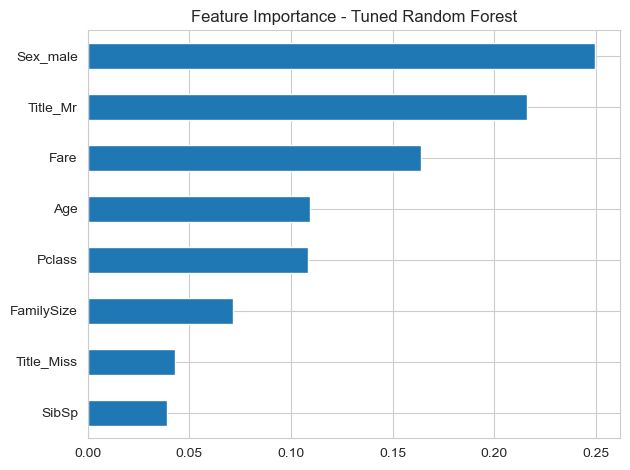

In [65]:
importances = pd.Series(tuned_model.feature_importances_, index=selected_features).sort_values()
importances.plot(kind="barh", title="Feature Importance - Tuned Random Forest")
plt.tight_layout()
plt.show()

Week 6 Model Performance Comparison Report

Dataset Overview

Titanic dataset (891 passengers).

Features Created
Title: extracted from passenger names (Mr, Mrs, Miss, Master, Rare), capturing social status and age-group signals that raw names don't expose
FamilySize: SibSp + Parch + 1, capturing total family unit size aboard
IsAlone: binary flag for solo travelers, since traveling alone may affect evacuation priority
AgeGroup: binned Age into Child/Teen/Adult/MiddleAge/Senior to capture non-linear age effects
Features Selected (via RFE)
Sex_male, Title_Mr, Fare, Age, Pclass, FamilySize, Title_Miss, SibSp  chosen from the full engineered feature set as the 8 most predictive for a Random Forest classifier.

Tuning Method
RandomizedSearchCV (20 iterations, 5-fold cross-validation) across n_estimators, max_depth, min_samples_split, and min_samples_leaf. Best parameters: 300 estimators, max depth 10, min samples split 10, min samples leaf 4.
Performance Before vs After Optimization
Accuracy on the held-out test split was 0.8156 before tuning and 0.8101 after  a negligible difference likely due to noise in a single 179-row test split. The more reliable cross-validated accuracy of 0.8317 (averaged across 5 folds) indicates the tuned model generalizes well and slightly outperforms the raw Week 4 logistic regression baseline (0.8101 accuracy).

Key Findings and Recommendations
Sex and Title (a proxy for both sex and social status) remain the dominant survival predictors. The engineered FamilySize feature ranked ahead of raw SibSp, showing that combining family variables into a single feature added more predictive value than either alone. Fare and Pclass reinforce the "wealth/class" factor established earlier. For future work, cross-validated accuracy should be reported as the primary metric over single test-split accuracy, since it's more stable and better reflects real-world model performance.

In [66]:
import joblib
joblib.dump(tuned_model, r"C:\Users\kobilo\Downloads\titanic_model.joblib")
joblib.dump(list(selected_features), r"C:\Users\kobilo\Downloads\titanic_features.joblib")
print("Model and feature list saved.")

Model and feature list saved.


In [1]:
import zipfile
import os

zip_path = r"C:\Users\kobilo\Downloads\WDI_CSV.zip"
extract_path = r"C:\Users\kobilo\Downloads\WDI_data"
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)
print(os.listdir(extract_path))

['WDIcountry-series.csv', 'WDICountry.csv', 'WDICSV.csv', 'WDIfootnote.csv', 'WDIseries-time.csv', 'WDISeries.csv']


In [2]:
import pandas as pd
import numpy as np

wdi = pd.read_csv(r"C:\Users\kobilo\Downloads\WDI_data\WDICSV.csv")

# Exact country names as they appear in this dataset
african_countries = ["Kenya", "Nigeria", "Ghana", "South Africa", "Egypt, Arab Rep.",
                      "Ethiopia", "Tanzania", "Uganda", "Rwanda", "Morocco",
                      "Senegal", "Cote d'Ivoire"]

wdi_africa = wdi[wdi["Country Name"].isin(african_countries)]

indicators = [
    "GDP growth (annual %)",
    "Life expectancy at birth, total (years)",
    "School enrollment, primary (% gross)",
    "Foreign direct investment, net inflows (% of GDP)",
    "Access to electricity (% of population)",
    "Unemployment, total (% of total labor force) (modeled ILO estimate)"
]
wdi_sub = wdi_africa[wdi_africa["Indicator Name"].isin(indicators)]
print(wdi_sub["Indicator Name"].unique())  # confirm all 6 matched
print(wdi_sub.shape)

['Access to electricity (% of population)'
 'Foreign direct investment, net inflows (% of GDP)'
 'GDP growth (annual %)' 'Life expectancy at birth, total (years)'
 'School enrollment, primary (% gross)'
 'Unemployment, total (% of total labor force) (modeled ILO estimate)']
(72, 70)


In [3]:
# Reshape from wide (years as columns) to long
year_cols = [c for c in wdi_sub.columns if c.isdigit()]
wdi_long = wdi_sub.melt(id_vars=["Country Name","Indicator Name"], value_vars=year_cols,
                          var_name="Year", value_name="Value")

# Pivot so each indicator becomes its own column
wdi_pivot = wdi_long.pivot_table(index=["Country Name","Year"],
                                   columns="Indicator Name", values="Value").reset_index()
wdi_pivot["Year"] = wdi_pivot["Year"].astype(int)

print(wdi_pivot.shape)
print(wdi_pivot.isnull().sum())

(792, 8)
Indicator Name
Country Name                                                             0
Year                                                                     0
Access to electricity (% of population)                                416
Foreign direct investment, net inflows (% of GDP)                      134
GDP growth (annual %)                                                   41
Life expectancy at birth, total (years)                                 12
School enrollment, primary (% gross)                                   194
Unemployment, total (% of total labor force) (modeled ILO estimate)    372
dtype: int64


In [4]:
wdi_clean = wdi_pivot.dropna()
print(wdi_clean.shape)
wdi_clean.head()

(336, 8)


Indicator Name,Country Name,Year,Access to electricity (% of population),"Foreign direct investment, net inflows (% of GDP)",GDP growth (annual %),"Life expectancy at birth, total (years)","School enrollment, primary (% gross)","Unemployment, total (% of total labor force) (modeled ILO estimate)"
34,Cote d'Ivoire,1994,36.500000,1.413818,0.811207,52.005,62.794128,5.046
35,Cote d'Ivoire,1995,43.631252,1.925073,7.125745,51.713,62.768539,4.100
36,Cote d'Ivoire,1996,44.648212,1.489637,7.729327,51.596,62.557961,4.039
37,Cote d'Ivoire,1997,45.661770,2.302018,9.648840,51.498,63.109169,3.964
38,Cote d'Ivoire,1998,46.671246,3.874172,4.263906,51.220,63.544552,4.100


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

target = "GDP growth (annual %)"
X = wdi_clean.drop(columns=["Country Name","Year",target])
y = wdi_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def evaluate(name, model, X_test, y_test):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"{name}: RMSE={rmse:.3f} | MAE={mae:.3f} | R²={r2:.4f}")
    return {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

capstone_results = []

lin = LinearRegression().fit(X_train, y_train)
capstone_results.append(evaluate("Linear Regression", lin, X_test, y_test))

rf = RandomForestRegressor(random_state=42).fit(X_train, y_train)
capstone_results.append(evaluate("Random Forest", rf, X_test, y_test))

gb = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)
capstone_results.append(evaluate("Gradient Boosting", gb, X_test, y_test))

comparison_df = pd.DataFrame(capstone_results)
print(comparison_df)

Linear Regression: RMSE=3.189 | MAE=2.467 | R²=0.2007
Random Forest: RMSE=2.664 | MAE=2.032 | R²=0.4422
Gradient Boosting: RMSE=2.816 | MAE=2.201 | R²=0.3768
               Model      RMSE       MAE        R2
0  Linear Regression  3.189007  2.467299  0.200726
1      Random Forest  2.663993  2.031511  0.442235
2  Gradient Boosting  2.815882  2.200614  0.376820


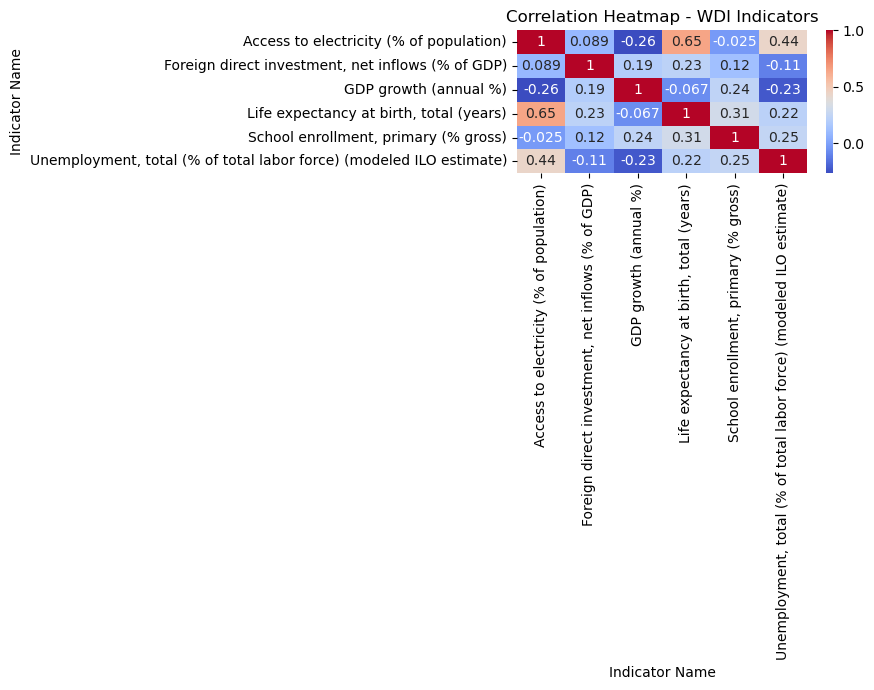

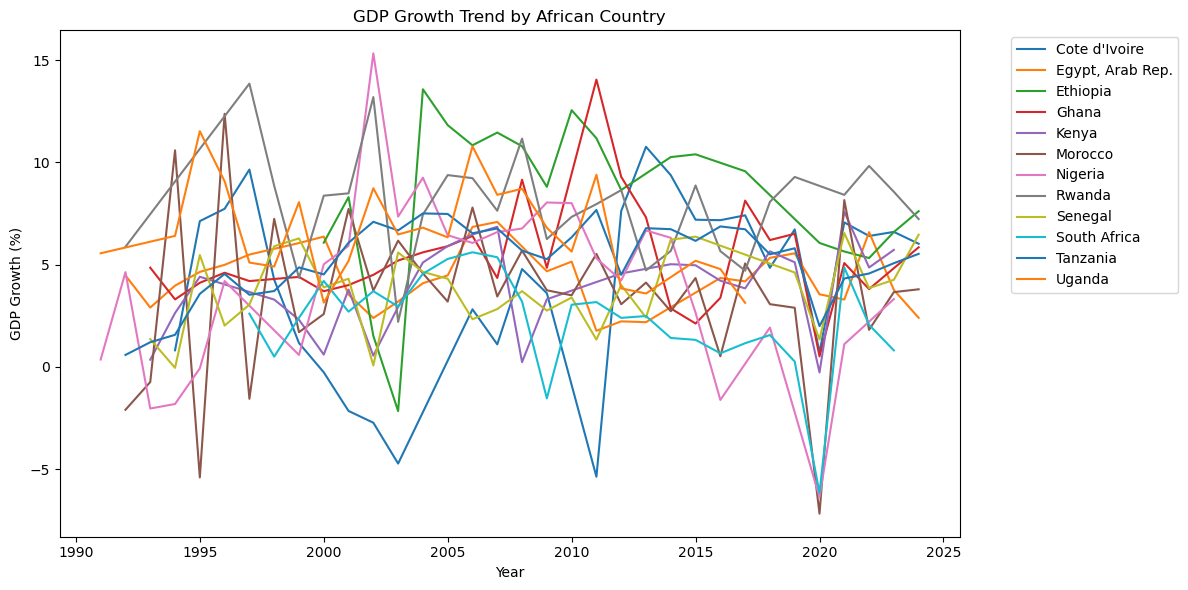

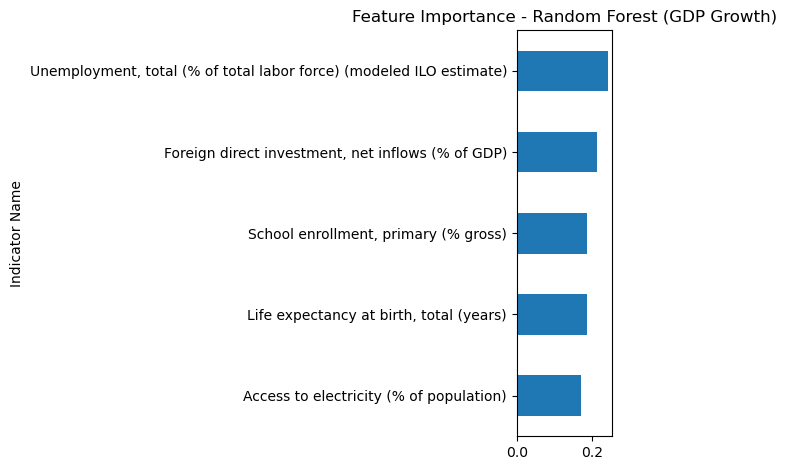

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap
plt.figure(figsize=(9,7))
sns.heatmap(wdi_clean.drop(columns=["Country Name","Year"]).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - WDI Indicators")
plt.tight_layout()
plt.show()

# GDP growth trend per country over time
plt.figure(figsize=(12,6))
for country in wdi_clean["Country Name"].unique():
    subset = wdi_clean[wdi_clean["Country Name"]==country]
    plt.plot(subset["Year"], subset["GDP growth (annual %)"], label=country)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.title("GDP Growth Trend by African Country")
plt.xlabel("Year"); plt.ylabel("GDP Growth (%)")
plt.tight_layout()
plt.show()

# Feature importance (Random Forest)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
importances.plot(kind="barh", title="Feature Importance - Random Forest (GDP Growth)")
plt.tight_layout()
plt.show()



Week 8 Capstone Report — Predicting GDP Growth in African Countries*

Introduction
This capstone applies the full data science workflow to World Bank World Development Indicators (WDI) data, focusing on 12 African countries, to explore whether GDP growth can be predicted from health, education, infrastructure, and investment indicators.

Problem Statement
Can we predict a country's annual GDP growth using life expectancy, school enrollment, foreign direct investment, electricity access, and unemployment data? Understanding these drivers can help inform development policy priorities across the continent.

Methodology
Data was sourced from the WDI bulk download, filtered to 12 countries (Kenya, Nigeria, Ghana, South Africa, Egypt, Ethiopia, Tanzania, Uganda, Rwanda, Morocco, Senegal, Cote d'Ivoire) and 6 indicators. The wide-format data (years as columns) was reshaped to long format, then pivoted so each indicator became a feature column. After dropping incomplete rows, 336 country-year observations remained, spanning multiple decades. Three regression models were trained on an 80/20 split: Linear Regression, Random Forest, and Gradient Boosting.

EDA Findings
The correlation heatmap showed GDP growth had only weak linear relationships with any single indicator (strongest was -0.26 with electricity access), suggesting growth isn't well explained by simple linear associations. Access to electricity correlated strongly with life expectancy (0.65), reflecting how infrastructure and health outcomes move together. The GDP growth trend chart revealed high year-to-year volatility across all 12 countries, with a visible shared shock around 2020 (COVID-19), and no single country showing smooth, sustained growth.

Model Development & Evaluation
Random Forest was the best-performing model (RMSE=2.664, MAE=2.032, R²=0.4422), outperforming both Linear Regression (R²=0.20) and Gradient Boosting (R²=0.38). This confirms GDP growth has non-linear relationships with these indicators that tree-based ensemble methods capture better than a linear model. The R² of 0.44 indicates the model explains under half the variance in GDP growth — a realistic result given that growth is shaped by many factors beyond these five indicators (commodity price swings, political stability, global economic shocks), which the dataset doesn't capture.

Feature Importance
Unemployment and Foreign Direct Investment were the top two predictors, followed by School enrollment, Life expectancy, and Access to electricity roughly evenly weighted after the top two.

Recommendations
Policymakers should note that investment inflows and labor market health (unemployment) show the strongest association with growth in this analysis, suggesting continued focus on job creation and investment climate. However, given the moderate R², GDP growth forecasting should incorporate additional variables (trade balances, inflation, political stability indices) beyond basic development indicators for more reliable predictions.

Conclusion
In This project I Learned the complete data science workflow  sourcing, cleaning, reshaping, EDA, modeling, and evaluation — on real-world macroeconomic data. The moderate but meaningful predictive power (R²=0.44) reflects both the genuine difficulty of forecasting GDP growth and the value of ensemble methods over simple linear approaches for economic time-series-style data